# Swin Transformer

**0 前言**<br>
&nbsp;&nbsp;&nbsp;&nbsp;0.1 Swin Transformer为什么会被提出？<br>
&nbsp;&nbsp;&nbsp;&nbsp;0.2 它主要想解决ViT的什么问题？<br>

**1 Swin Transformer的核心处理机制**<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1 Window Attention在做什么？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2 Shifted Window为什么能建立跨窗口连接？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.3 W-MSA与SW-MSA是如何交替工作的？<br>

**2 Swin Transformer的整体框架**<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1 从Patch Partition到Linear Embedding<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2 为什么它是层次化Transformer？<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.3 Patch Merging怎样实现尺度变化？<br>

<font color="red">**3 Swin Transformer的完整流程**</font><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1 一张图进入Swin后会经历哪些步骤？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2 各个Stage中的特征图尺寸如何变化？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3 最后如何得到视觉任务需要的输出表示？<br>

**4 学习Swin时最该抓住的几个点**<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1 它和ViT最本质的区别是什么？<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2 “局部计算 + 跨窗连接 + 层次化表示”该如何整体理解？<br>


## 3 Swin Transformer的完整流程

前两章已经分别解决了两个关键问题：

- `第 1 章` 讲清了 shifted window 这套注意力机制怎么工作
- `第 2 章` 讲清了 Swin 的层次化框架、stage 结构和 patch merging

这一章不再重复解释这些局部原理，而是做一件更直接的事：

**顺着一张输入图像，完整走一遍 Swin Transformer 的数据流。**

也就是说，我们关心的不再是“某一个模块单独是什么意思”，而是：

- 图像最开始怎么进来
- 中间依次经过哪些 stage
- 特征图尺寸怎样一步步变化
- 最后怎样变成分类、检测、分割等任务能使用的输出表示

所以这一章的重点，是把前面已经学过的模块重新串起来，形成一条完整、连续的数据流主线。

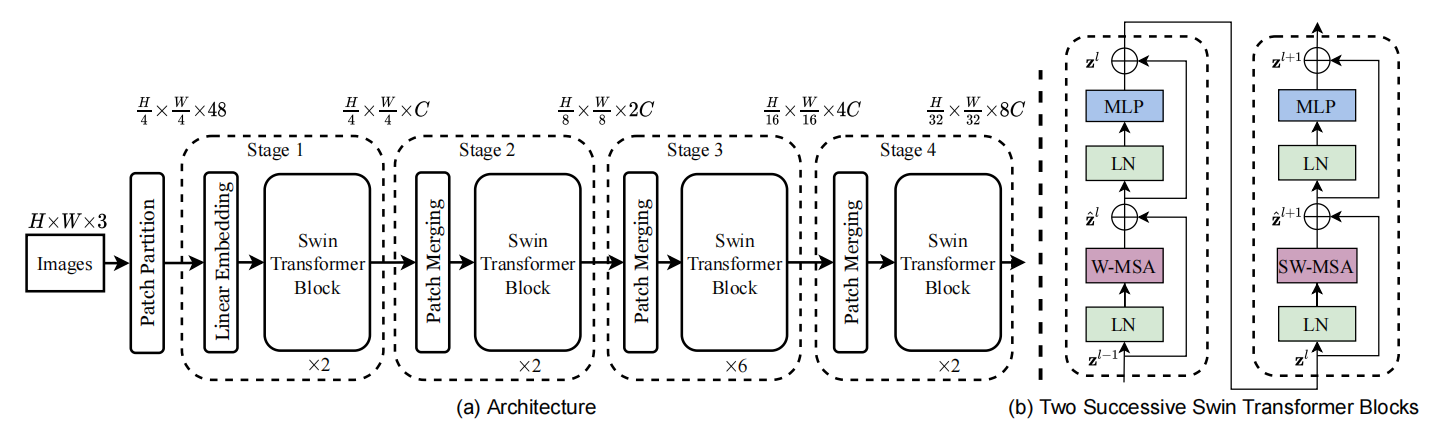

### 3.1 一张图进入Swin后会经历哪些步骤？

如果把整条流程先压成一句话，那么 Swin Transformer 的主线可以写成：

`输入图像 -> Patch Partition -> Linear Embedding -> Stage 1 -> Patch Merging -> Stage 2 -> Patch Merging -> Stage 3 -> Patch Merging -> Stage 4 -> 输出头`

这就是它最核心的前向流程。

顺着这条链条展开看，一张图进入 Swin 后，通常会依次经历下面几步：

1. **输入图像**
   输入是一张 `H × W × 3` 的 RGB 图像。这里先不用多想，重要的是后面所有处理都会围绕它的二维空间结构展开。

2. **Patch Partition**
   图像先被切成很多个不重叠的小 patch。Swin 里常见的是 `4 × 4` patch，所以原图会先从像素网格被改写成 patch 网格。

3. **Linear Embedding**
   每个 patch 再被映射成固定维度的向量，于是模型得到第一张 patch-level 特征图。到这一步，图像已经不再以原始像素形式存在，而是变成了一张低分辨率、高通道的特征表示。

4. **Stage 1**
   在第一阶段，模型会在当前分辨率上堆叠若干个 Swin block。这里 block 内部就是前一章讲过的 `W-MSA` 和 `SW-MSA` 交替工作。也就是说，Stage 1 的任务是在最细一级 patch 表示上先完成局部建模和初步跨窗口传播。

5. **Patch Merging**
   Stage 1 结束后，不会直接进入下一层相同尺度的 block，而是先做一次 `Patch Merging`。这一步让空间分辨率减半、通道维度增大，于是特征图进入下一层级。

6. **Stage 2 / Stage 3 / Stage 4**
   后面几个 stage 都遵循同样的节奏：
   在当前尺度上先用若干个 Swin block 充分建模，再在 stage 末尾通过 patch merging 进入下一尺度。这样随着层数加深，模型会逐步从细粒度局部表示走向更粗粒度、更高语义的表示。

7. **输出头**
   当最后一个 stage 结束后，模型已经得到一张语义很强的高层特征图。接下来怎么用它，就取决于具体任务：
   分类任务会进一步汇聚成全局表示；检测、分割任务则会把不同 stage 的特征拿去接后续预测头。

所以从流程上看，Swin 的关键节奏其实非常清楚：

- 先把图像变成 patch-level 特征图
- 再在每个 stage 内做局部窗口 Transformer 建模
- 然后在 stage 之间逐步做尺度变化
- 最后把最高层或多层特征送给具体任务头

这也是为什么说 Swin 虽然内部仍然是 Transformer block，但整体看起来已经很像一个标准视觉 backbone 了。

### 3.2 各个Stage中的特征图尺寸如何变化？

理解完整流程时，最重要的一条主线就是：**特征图尺寸怎么变。**

因为 Swin 的“层次化”不是一句抽象描述，而是会真实体现在每个 stage 的空间分辨率和通道维度上。

假设输入图像大小是论文里很常见的：

$$
224 \times 224 \times 3
$$

同时 patch size 取 `4 × 4`，初始通道维度记作 `C`。那么整个 Swin 的尺寸变化可以直接按 stage 写出来：

1. **输入图像**
   `224 × 224 × 3`

2. **Patch Partition + Linear Embedding 之后**
   `56 × 56 × C`

3. **Stage 1 输出**
   仍然是 `56 × 56 × C`

4. **第一次 Patch Merging 之后 / Stage 2 输入**
   `28 × 28 × 2C`

5. **Stage 2 输出**
   仍然是 `28 × 28 × 2C`

6. **第二次 Patch Merging 之后 / Stage 3 输入**
   `14 × 14 × 4C`

7. **Stage 3 输出**
   仍然是 `14 × 14 × 4C`

8. **第三次 Patch Merging 之后 / Stage 4 输入**
   `7 × 7 × 8C`

9. **Stage 4 输出**
   仍然是 `7 × 7 × 8C`

这里最该抓住的是两个规律：

- **在同一个 stage 内，特征图尺寸不变**
- **只有在 stage 之间，才通过 patch merging 改变尺度**

也就是说，Swin 的尺寸变化不是“每一层都在变”，而是“分段地变”。这和很多 CNN 主干很像：先在当前分辨率上提够特征，再统一进入下一层级。

再把这条主线压缩一下，就是：

$$
224 \times 224 \times 3
\rightarrow 56 \times 56 \times C
\rightarrow 28 \times 28 \times 2C
\rightarrow 14 \times 14 \times 4C
\rightarrow 7 \times 7 \times 8C
$$

从这个角度看，Swin 的完整流程其实非常工整：

- 原图先通过 patch 切分被降到 `1/4` 尺度
- 后面每经过一次 patch merging，空间再缩小一半
- 与此同时，通道按 `C -> 2C -> 4C -> 8C` 逐步增加

所以当你看一张 Swin 结构图时，不要被各种 block 画法分散注意力。真正该盯住的，是这条尺寸演化主线。因为它决定了每个 stage 在整条数据流里的位置和作用。

### 3.3 最后如何得到视觉任务需要的输出表示？

到了最后一个 stage，Swin 已经得到了一张高层语义特征图。接下来真正的问题是：**这张特征图怎样变成具体任务需要的输出？**

这一点要分任务来看。

#### 3.3.1 分类任务怎么做？

对于图像分类，目标是给整张图输出一个类别。因此模型最后并不需要保留每个空间位置的独立预测，而是要把整张图的信息汇聚成一个全局表示。

Swin 的做法和标准 ViT 有一个明显区别：**它通常不依赖 `CLS token` 来做最终分类汇聚。**

更自然的方式是：

- 先拿到最后一个 stage 的特征图，比如 `7 × 7 × 8C`
- 再对所有空间位置做全局平均池化或等价的全局汇聚
- 得到一个整张图的全局特征向量
- 最后接一个线性分类头输出类别分数

所以分类任务下，完整末端流程可以理解成：

`Stage 4 特征图 -> 全局汇聚 -> 图像级向量 -> 分类头`

这里最重要的是理解：前面层次化 backbone 的工作，是逐步把图像编码成越来越抽象的特征图；最后这个汇聚步骤，才把它压成“整张图对应一个向量”的形式。

#### 3.3.2 检测和分割任务怎么做？

如果任务变成目标检测、实例分割、语义分割这类 dense prediction 问题，情况就不一样了。

这时模型不能只留下一个全局向量，因为：

- 检测需要知道目标在哪里
- 分割需要知道每个区域甚至每个像素属于什么类别

所以这类任务通常不会只拿最后一个 stage 的单一输出，而是会利用 **多个 stage 的特征图**。

原因很直接：

- 低层 stage 分辨率更高，保留更多局部细节
- 高层 stage 语义更强，更适合识别目标类别和整体结构

因此，在检测或分割框架里，Swin 更像一个通用 backbone。它会把 `Stage 1 ~ Stage 4` 的多尺度特征输出给后续 neck / head，再由这些模块去完成框选、分类、掩码预测或像素级分类。

所以这里应该把 Swin 理解成：

**它负责提供一组层次化的视觉特征，而不是替所有视觉任务预先规定唯一的最终输出形式。**

#### 3.3.3 为什么这种输出方式很重要？

这一点和前面讲的层次化结构正好呼应起来。

如果一个 backbone 只能产出固定尺度、固定形式的最终表示，那么它做分类也许够用，但做检测和分割时就会显得别扭。

而 Swin 的好处在于：

- 做分类时，可以把最后高层特征进一步汇聚成全局表示
- 做检测、分割时，又可以把多 stage 特征直接接入后续模块

这就是它为什么被称为“通用视觉 backbone”。

从完整流程的最后一段来看，Swin 并不是在说“我只服务某一种输出头”，而是在说：

**我先把图像加工成层次化的多尺度特征，至于最后怎么把这些特征变成任务输出，由具体任务头决定。**

#### 3.3.4 把第三章压成一句话

如果把整章压成一句最核心的话，那就是：

**Swin Transformer 的完整流程，就是先把图像变成 patch-level 特征图，再经过多个 stage 的局部窗口建模和尺度变化，最后输出适合分类任务全局汇聚、也适合检测分割任务多尺度使用的一组层次化特征。**

这条流程主线一旦清楚，前面所有模块的位置就都能对上号：

- `Shifted window` 解释的是 stage 内部怎么高效建模
- `Patch merging` 解释的是 stage 之间怎么切换尺度
- `完整流程` 解释的是它们怎样共同组成一个真正可用的视觉主干
